# Computer Vision Brain Tumor Classification (MRI)

**Programmed Project II IC-6200 Artificial Intelligence**  
**Dataset:** [Brain Tumor MRI Dataset (Kaggle)](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

---

Students:

*   **Ovidio Martínez Taleno**
*   **Noelia Sandoval Marín**
---
## Problem Description

This module implements a medical image classification system to detect and classify brain tumors from MRI scans. The dataset contains 4 classes:

| Class | Description |
|---|---|
| `glioma` | Glial tissue tumor (malignant) |
| `meningioma` | Meningeal tumor (generally benign) |
| `pituitary` | Pituitary gland tumor |
| `notumor` | No tumor (normal image) |

## Module Objectives

1. Load and preprocess the MRI dataset (≥200 images, the dataset has 7200)
2. Implement Transfer Learning with ≥2 base models (ResNet50V2 and EfficientNetB0)
3. Compare both models using metrics: Accuracy, Precision, Recall, F1-Score
4. Visualize results: confusion matrices, training curves, and Grad-CAM

---


## 1. Library Imports


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# mount Google Drive and Configure Paths
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/AI(Data set)/ProyectoData/archive/Training'
DATA_DIR_TEST = '/content/drive/MyDrive/AI(Data set)/ProyectoData/archive/Testing'

import os
print('Classes found in Training:', os.listdir(DATA_DIR))
print('Classes found in Testing: ', os.listdir(DATA_DIR_TEST))

Mounted at /content/drive
Classes found in Training: ['notumor', 'meningioma', 'glioma', 'pituitary']
Classes found in Testing:  ['notumor', 'meningioma', 'pituitary', 'glioma']


## 2. Global Hyperparameter Configuration


In [ ]:
# Hyperparameters
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_FE   = 15
EPOCHS_FT   = 10
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print(f'Image: {IMG_SIZE}x{IMG_SIZE} | Batch: {BATCH_SIZE} | Classes: {NUM_CLASSES}')


Image: 224x224 | Batch: 32 | Classes: 4


## 3. Dataset Loading and Exploration


In [ ]:
# count images per class
print('=== TRAINING SET ===')
total_train = 0
for clase in os.listdir(DATA_DIR):
    ruta = os.path.join(DATA_DIR, clase)
    n = len(os.listdir(ruta))
    total_train += n
    print(f'  {clase:15s}: {n} images')
print(f'  TOTAL: {total_train}\n')

print('=== TESTING SET ===')
total_test = 0
for clase in os.listdir(DATA_DIR_TEST):
    ruta = os.path.join(DATA_DIR_TEST, clase)
    n = len(os.listdir(ruta))
    total_test += n
    print(f'  {clase:15s}: {n} images')
print(f'  TOTAL: {total_test}')


=== TRAINING SET ===
  notumor        : 1400 images
  meningioma     : 1400 images
  glioma         : 1400 images
  pituitary      : 1400 images
  TOTAL: 5600

=== TESTING SET ===
  notumor        : 400 images
  meningioma     : 400 images
  pituitary      : 400 images
  glioma         : 400 images
  TOTAL: 1600


=== CLASS DISTRIBUTION (Training) ===
  glioma         : 1400 images
  meningioma     : 1400 images
  notumor        : 1400 images
  pituitary      : 1400 images
  TOTAL: 5600

Imbalance ratio (max/min): 1.00x
 Relatively balanced dataset.

 Computed class weights:
  0 (glioma      ): 1.0000
  1 (meningioma  ): 1.0000
  2 (notumor     ): 1.0000
  3 (pituitary   ): 1.0000


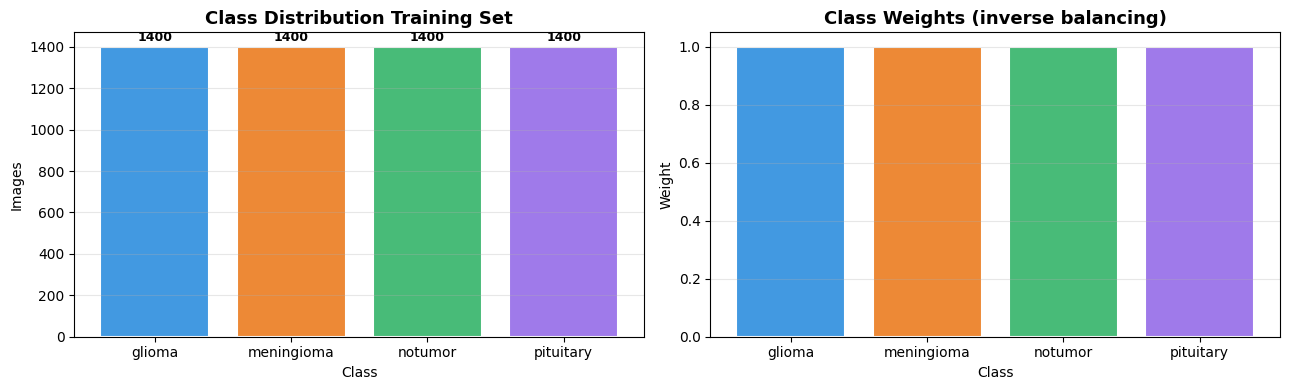

In [ ]:
# Count images
from sklearn.utils.class_weight import compute_class_weight

counts = {}
for clase in sorted(os.listdir(DATA_DIR)):
    ruta = os.path.join(DATA_DIR, clase)
    if os.path.isdir(ruta):
        counts[clase] = len(os.listdir(ruta))

print('=== CLASS DISTRIBUTION (Training) ===')
for clase, n in counts.items():
    print(f'  {clase:15s}: {n} images')
print(f'  TOTAL: {sum(counts.values())}\n')

vals = list(counts.values())
ratio = max(vals) / min(vals)
print(f'Imbalance ratio (max/min): {ratio:.2f}x')
if ratio > 1.5:
    print(' Imbalance detected class_weights will be applied during training.')
else:
    print(' Relatively balanced dataset.')

y_labels_all = []
for idx, clase in enumerate(sorted(counts.keys())):
    y_labels_all.extend([idx] * counts[clase])
import numpy as np
y_labels_all = np.array(y_labels_all)

cw_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels_all),
    y=y_labels_all
)
CLASS_WEIGHTS = dict(enumerate(cw_values))
print('\n Computed class weights:')
for i, (clase, w) in enumerate(zip(sorted(counts.keys()), cw_values)):
    print(f'  {i} ({clase:12s}): {w:.4f}')

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#4299e1', '#ed8936', '#48bb78', '#9f7aea']
bars = ax1.bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=9)
ax1.set_title('Class Distribution Training Set', fontsize=13, fontweight='bold')
ax1.set_xlabel('Class'); ax1.set_ylabel('Images')
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(sorted(counts.keys()), cw_values, color=colors, edgecolor='white', linewidth=1.5)
ax2.set_title('Class Weights (inverse balancing)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Class'); ax2.set_ylabel('Weight')
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


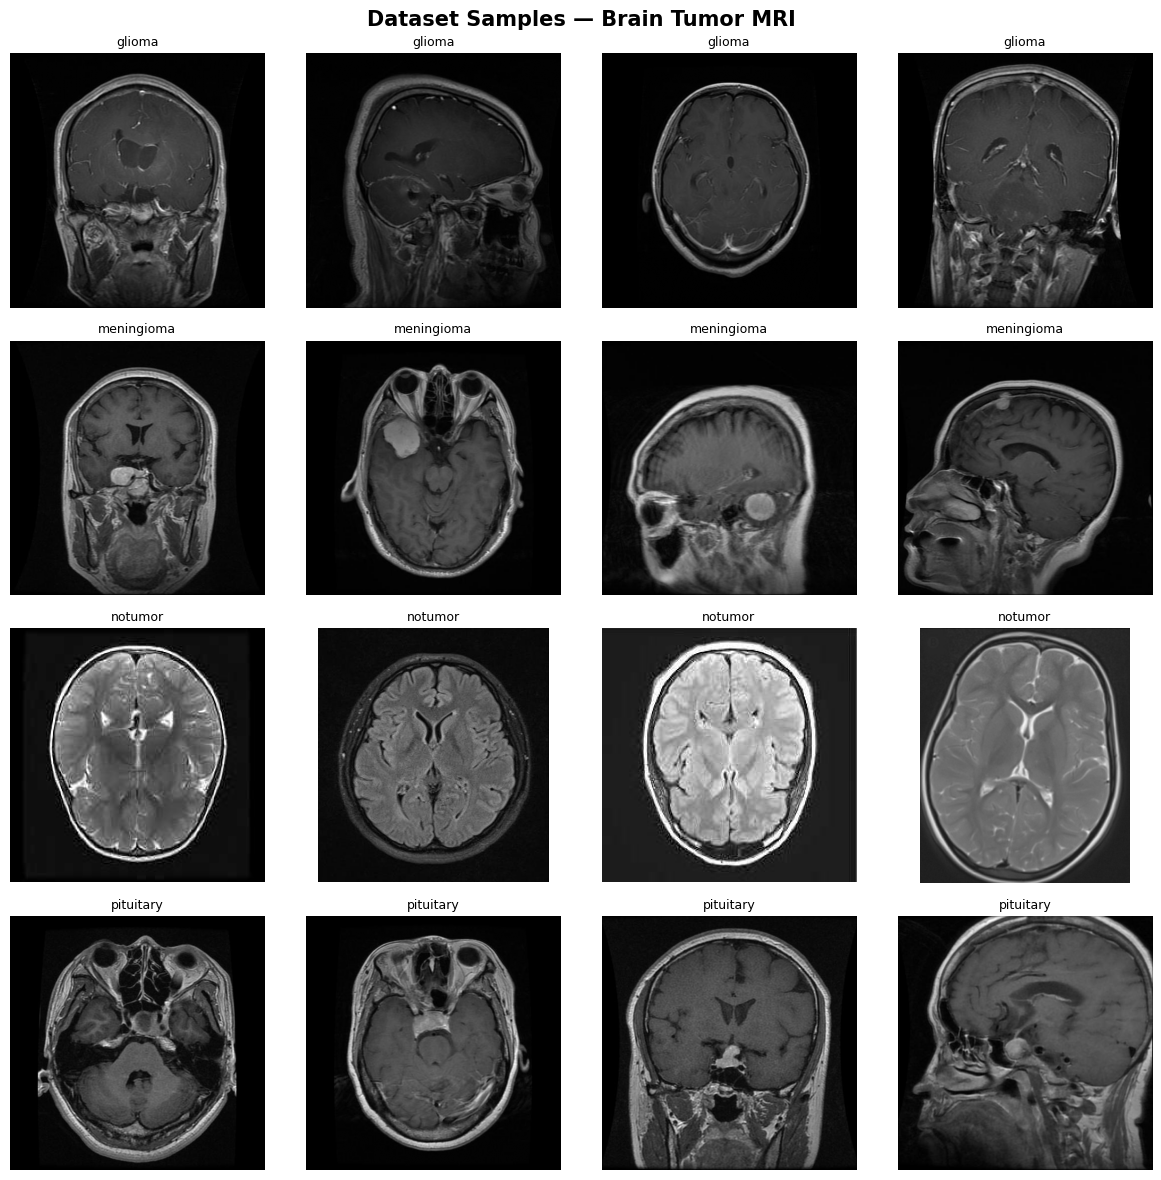

In [ ]:
#  visualize sample images per class
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Dataset Samples — Brain Tumor MRI', fontsize=15, fontweight='bold')

for i, clase in enumerate(CLASS_NAMES):
    ruta_clase = os.path.join(DATA_DIR, clase)
    archivos = random.sample(os.listdir(ruta_clase), 4)
    for j, archivo in enumerate(archivos):
        img_path = os.path.join(ruta_clase, archivo)
        img = plt.imread(img_path)
        axes[i][j].imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        axes[i][j].set_title(clase, fontsize=9)
        axes[i][j].axis('off')

plt.tight_layout()
plt.show()


## 4. Preprocessing and Data Augmentation

> **normalization:**  
> - **ResNet50V2** has no internal preprocessing  rescale=1./255 is applied to normalize to [0,1].  
> - **EfficientNetB0** includes an internal Rescaling layer that expects pixels in [0, 255]  no external rescale is applied; otherwise double normalization occurs and the model receives values in [0, 0.004], degrading performance.  

Two independent sets of generators are created, one for each architecture.


In [ ]:
# Common augmentation for both models
augmentation_params = dict(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    validation_split=0.2
)

# for ResNet50V2: rescale=1/255
gen_resnet_train = ImageDataGenerator(rescale=1./255, **augmentation_params)
gen_resnet_test  = ImageDataGenerator(rescale=1./255)

# For EfficientNetB0: no rescale
gen_eff_train = ImageDataGenerator(**augmentation_params)
gen_eff_test  = ImageDataGenerator()

def create_generators(gen_train, gen_test, seed=42):
    """Creates the three generators (train/val/test) for a given ImageDataGenerator."""
    train = gen_train.flow_from_directory(
        DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='categorical', subset='training', seed=seed, shuffle=True
    )
    val = gen_train.flow_from_directory(
        DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='categorical', subset='validation', seed=seed, shuffle=False
    )
    test = gen_test.flow_from_directory(
        DATA_DIR_TEST, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False
    )
    return train, val, test

print('=== ResNet50V2 Generators (rescale=1/255) ===')
train_gen_r, val_gen_r, test_gen_r = create_generators(gen_resnet_train, gen_resnet_test)

print('\n=== EfficientNetB0 Generators (no rescale) ===')
train_gen_e, val_gen_e, test_gen_e = create_generators(gen_eff_train, gen_eff_test)

print(f'\nClass map: {train_gen_r.class_indices}')
print(f'Train: {train_gen_r.samples} | Val: {val_gen_r.samples} | Test: {test_gen_r.samples}')

train_gen = train_gen_r
val_gen   = val_gen_r
test_gen  = test_gen_r


=== ResNet50V2 Generators (rescale=1/255) ===
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

=== EfficientNetB0 Generators (no rescale) ===
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class map: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train: 4480 | Val: 1120 | Test: 1600


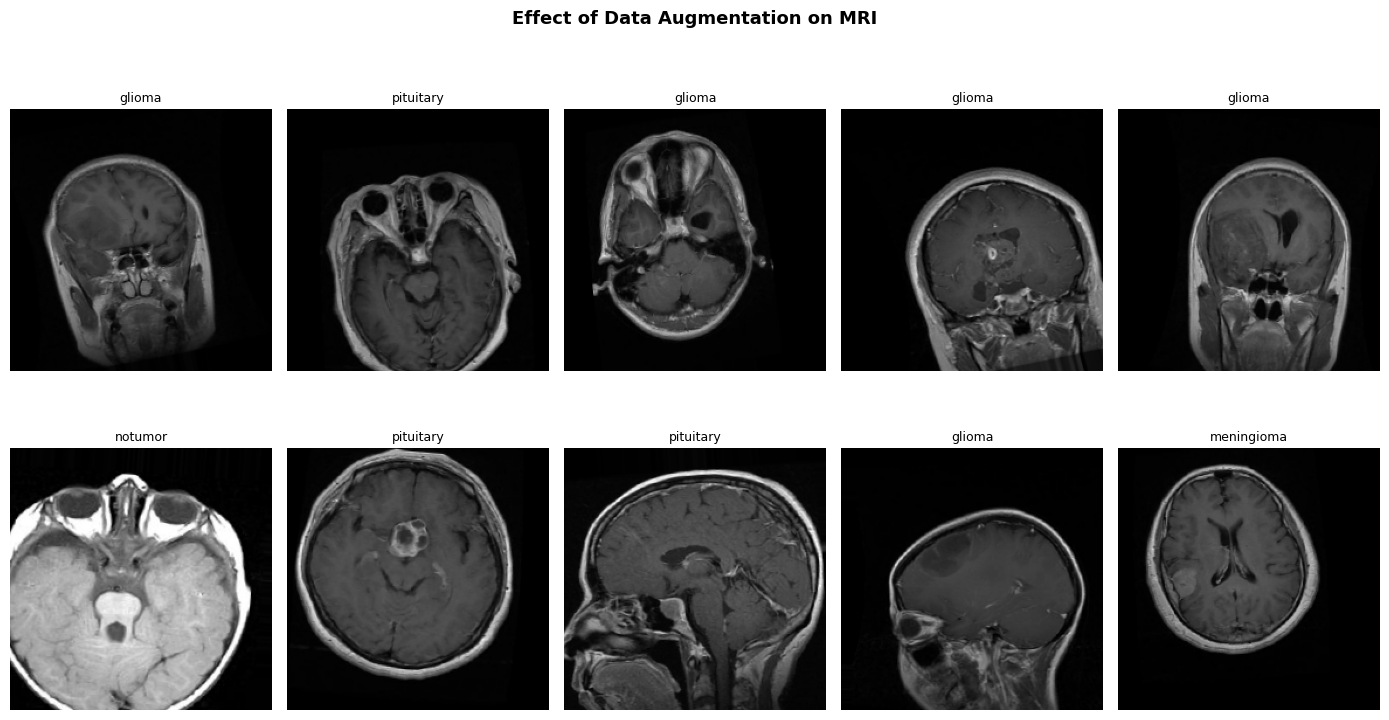

In [ ]:
sample_images, sample_labels = next(train_gen)

fig, axes = plt.subplots(2, 5, figsize=(14, 8))
fig.suptitle('Effect of Data Augmentation on MRI', fontsize=13, fontweight='bold')
label_names = {v: k for k, v in train_gen.class_indices.items()}

for i in range(10):
    ax = axes[i // 5][i % 5]
    ax.imshow(sample_images[i])
    ax.set_title(label_names[np.argmax(sample_labels[i])], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 5. Utility Functions (Callbacks and Plots)

Standard callbacks are defined: EarlyStopping (stops training if val_loss does not improve) and ReduceLROnPlateau (reduces the learning rate when the loss stagnates).


In [ ]:
def get_callbacks(model_name):
    """standard callbacks for training."""
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'/content/best_{model_name}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]


def plot_history(history, title):
    """plots the accuracy and loss training curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training Curves — {title}', fontsize=14, fontweight='bold')

    # Accuracy
    ax1.plot(history.history['accuracy'],     label='Train Acc',  color='#4299e1', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Acc',    color='#ed8936', linewidth=2, linestyle='--')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'],         label='Train Loss', color='#48bb78', linewidth=2)
    ax2.plot(history.history['val_loss'],     label='Val Loss',   color='#9f7aea', linewidth=2, linestyle='--')
    ax2.set_title('Loss (Categorical Crossentropy)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title):
    """plots the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prediction')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    plt.show()


def compute_metrics(y_true, y_pred, name):
    """computes and returns classification metrics."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'\n{"="*50}')
    print(f'  METRICS — {name}')
    print(f'{"="*50}')
    print(f'  Accuracy :  {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision:  {prec:.4f}')
    print(f'  Recall   :  {rec:.4f}')
    print(f'  F1-Score :  {f1:.4f}')
    print(f'{"="*50}')
    print()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}


print(' Utility functions defined.')


 Utility functions defined.


## 6. Model 1: Transfer Learning with ResNet50V2

> **ResNet50V2** Residual Network: a 50 layer architecture with residual connections that allow training very deep networks without the vanishing gradient problem.

Strategy: Feature Extraction : Fine Tuning

> Agregar bloque entrecomillado




In [ ]:
def build_resnet_model():
    """
    Builds the model with ResNet50V2 as the pre-trained base.
    Architecture: ResNet50V2 base (frozen) -> GlobalAveragePooling -> Dense(256) -> Dropout -> Softmax
    """
    # feature Extraction
    base_resnet = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_resnet.trainable = False

    # New classifier
    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base_resnet(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='ResNet50V2_BrainTumor')
    return model, base_resnet


modelo_resnet, base_resnet = build_resnet_model()

modelo_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_resnet.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50V2_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,130,948 (92.05 MB)

 Trainable params: 562,052 (2.14 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

In [ ]:
# Feature Extraction
print('PHASE 1: Feature Extraction (ResNet50V2 frozen)\n')
print(f'   Trainable layers: {sum(1 for l in modelo_resnet.layers if l.trainable)}')
print(f'   Frozen layers   : {sum(1 for l in modelo_resnet.layers if not l.trainable)}\n')
print('   Generators: rescale = 1/255 ')
print('   Class weights applied: \n')

history_resnet_fe = modelo_resnet.fit(
    train_gen_r,
    validation_data=val_gen_r,
    epochs=EPOCHS_FE,
    class_weight=CLASS_WEIGHTS,
    callbacks=get_callbacks('resnet_fe'),
    verbose=1
)


PHASE 1: Feature Extraction (ResNet50V2 frozen)

   Trainable layers: 8
   Frozen layers   : 1

   Generators: rescale = 1/255 
   Class weights applied: 

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1652s 12s/step - accuracy: 0.7746 - loss: 0.6464 - val_accuracy: 0.8643 - val_loss: 0.3546 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 125s 892ms/step - accuracy: 0.8638 - loss: 0.3746 - val_accuracy: 0.8982 - val_loss: 0.2918 - learning_rate: 0.0010
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 103s 735ms/step - accuracy: 0.8819 - loss: 0.3323 - val_accuracy: 0.9071 - val_loss: 0.2606 - learning_rate: 0.0010
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 101s 718ms/step - accuracy: 0.8935 - loss: 0.2899 - val_accuracy: 0.9018 - val_loss: 0.2496 - learning_rate: 0.0010
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 101s 722ms/step - accuracy: 0.9000 - loss: 0.2667 - val_accuracy: 0.9062 - val_loss: 0.2367 - learning_rate: 0.0010
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 741ms/step - accurac

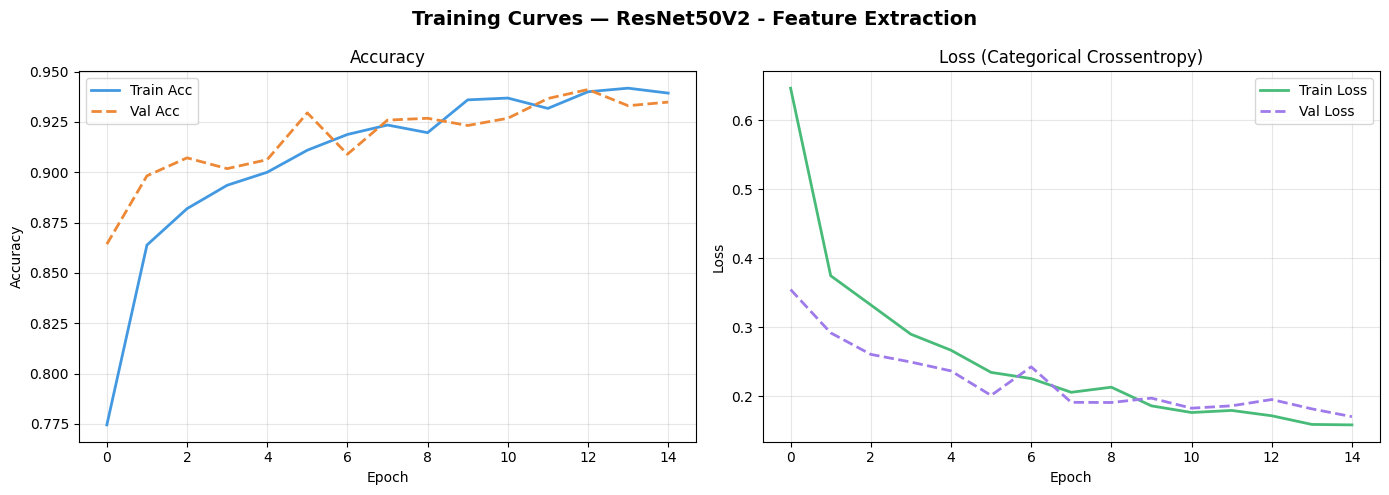

In [ ]:
plot_history(history_resnet_fe, 'ResNet50V2 - Feature Extraction')


In [ ]:
# fine Tuning
print('PHASE 2 Fine-Tuning (ResNet50V2 partially unfrozen)\n')

base_resnet.trainable = True
for layer in base_resnet.layers[:-30]:
    layer.trainable = False

modelo_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Trainable layers: {sum(1 for l in base_resnet.layers if l.trainable)} (last 30 of ResNet)')
history_resnet_ft = modelo_resnet.fit(
    train_gen_r,
    validation_data=val_gen_r,
    epochs=EPOCHS_FT,
    class_weight=CLASS_WEIGHTS,
    callbacks=get_callbacks('resnet_ft'),
    verbose=1
)

PHASE 2 Fine-Tuning (ResNet50V2 partially unfrozen)

   Trainable layers: 30 (last 30 of ResNet)
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 128s 776ms/step - accuracy: 0.9129 - loss: 0.2444 - val_accuracy: 0.9250 - val_loss: 0.2084 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 738ms/step - accuracy: 0.9371 - loss: 0.1737 - val_accuracy: 0.9250 - val_loss: 0.1904 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 741ms/step - accuracy: 0.9484 - loss: 0.1413 - val_accuracy: 0.9429 - val_loss: 0.1684 - learning_rate: 1.0000e-05
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 102s 727ms/step - accuracy: 0.9536 - loss: 0.1211 - val_accuracy: 0.9375 - val_loss: 0.1864 - learning_rate: 1.0000e-05
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 103s 733ms/step - accuracy: 0.9600 - loss: 0.1104 - val_accuracy: 0.9482 - val_loss: 0.1477 - learning_rate: 1.0000e-05
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 103s 736ms/step - accuracy: 0.9643 - loss: 0.1062 - val_accurac

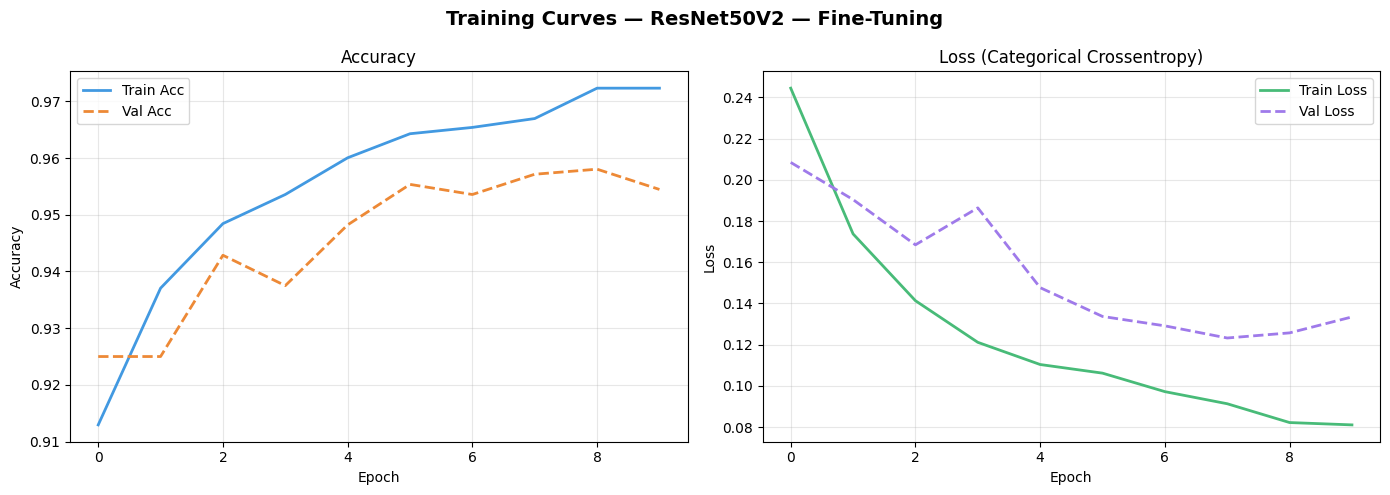

In [ ]:
plot_history(history_resnet_ft, 'ResNet50V2 — Fine-Tuning')

Evaluating ResNet50V2 on the Test Set

50/50 ━━━━━━━━━━━━━━━━━━━━ 636s 13s/step

  METRICS — ResNet50V2
  Accuracy :  0.9237  (92.38%)
  Precision:  0.9267
  Recall   :  0.9237
  F1-Score :  0.9224

              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.87      0.91      0.89       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.92      0.98      0.95       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



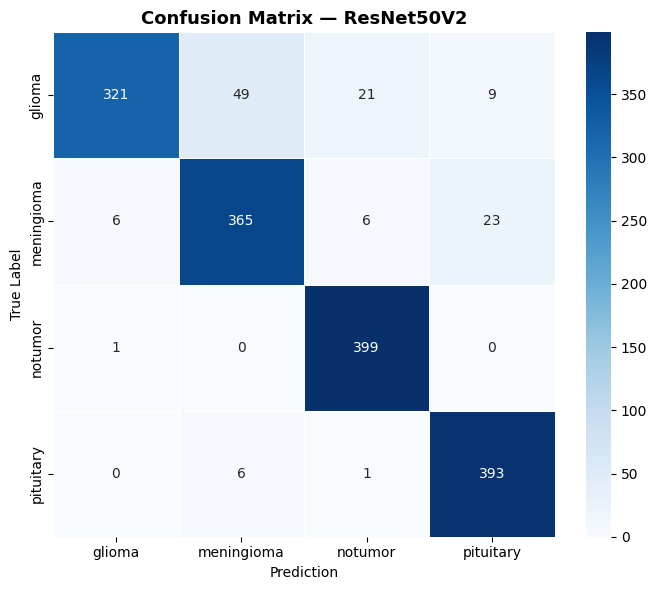

In [ ]:
# ResNet50V2 Evaluation on Test Set
print('Evaluating ResNet50V2 on the Test Set\n')

test_gen_r.reset()
y_pred_resnet_probs = modelo_resnet.predict(test_gen_r, verbose=1)
y_pred_resnet = np.argmax(y_pred_resnet_probs, axis=1)
y_true = test_gen_r.classes

metrics_resnet = compute_metrics(y_true, y_pred_resnet, 'ResNet50V2')
plot_confusion_matrix(y_true, y_pred_resnet, 'ResNet50V2')


## 7. Model 2: Transfer Learning with EfficientNetB0

> **EfficientNetB0**: architecture that scales network depth, width, and resolution in a balanced manner via compound scaling. Achieves high accuracy with fewer parameters than ResNet. Pre-trained on ImageNet.

Strategy: Feature Extraction : Fine Tuning


In [ ]:
def build_efficientnet_model():
    """
    Builds the model with EfficientNetB0 as the pre trained base.
    Architecture: EfficientNetB0 base (frozen) -> GlobalAveragePooling -> Dense(256) -> Dropout -> Softmax
    """

    base_eff = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_eff.trainable = False

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base_eff(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='EfficientNetB0_BrainTumor')
    return model, base_eff


modelo_eff, base_eff = build_efficientnet_model()

modelo_eff.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_eff.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,039 (16.85 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# feature Extraction
print('PHASE 1: Feature Extraction (EfficientNetB0 frozen)\n')
print('   Generators: No external rescale (EfficientNet has internal Rescaling)')
print('   Class weights applied:\n')

history_eff_fe = modelo_eff.fit(
    train_gen_e,
    validation_data=val_gen_e,
    epochs=EPOCHS_FE,
    class_weight=CLASS_WEIGHTS,
    callbacks=get_callbacks('eff_fe'),
    verbose=1
)


PHASE 1: Feature Extraction (EfficientNetB0 frozen)

   Generators: No external rescale (EfficientNet has internal Rescaling)
   Class weights applied:

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 137s 760ms/step - accuracy: 0.7455 - loss: 0.7054 - val_accuracy: 0.8571 - val_loss: 0.5124 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 98s 700ms/step - accuracy: 0.8252 - loss: 0.4519 - val_accuracy: 0.8929 - val_loss: 0.3634 - learning_rate: 0.0010
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 707ms/step - accuracy: 0.8489 - loss: 0.3885 - val_accuracy: 0.9045 - val_loss: 0.2989 - learning_rate: 0.0010
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 100s 714ms/step - accuracy: 0.8708 - loss: 0.3449 - val_accuracy: 0.9009 - val_loss: 0.2644 - learning_rate: 0.0010
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 707ms/step - accuracy: 0.8875 - loss: 0.3011 - val_accuracy: 0.9125 - val_loss: 0.2424 - learning_rate: 0.0010
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 710ms/step - accuracy: 0.8

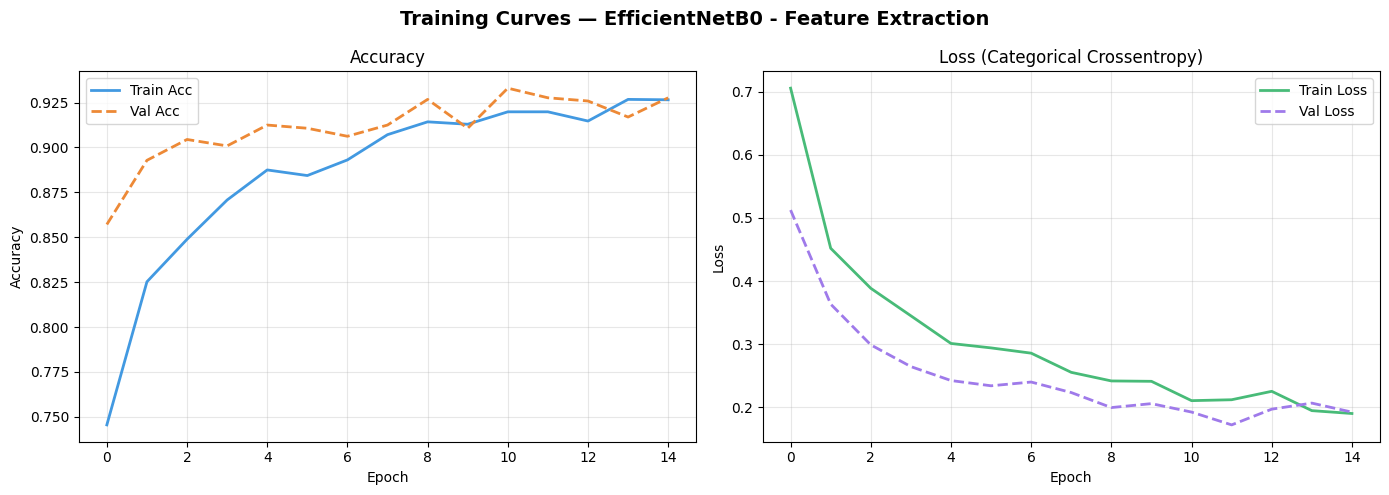

In [ ]:
plot_history(history_eff_fe, 'EfficientNetB0 - Feature Extraction')

In [ ]:
# fine-Tuning
print('PHASE 2:  Fine Tuning (EfficientNetB0 partially unfrozen)\n')

base_eff.trainable = True
for layer in base_eff.layers[:-20]:
    layer.trainable = False

modelo_eff.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Trainable layers: {sum(1 for l in base_eff.layers if l.trainable)} (last 20 of EfficientNet)')

history_eff_ft = modelo_eff.fit(
    train_gen_e,
    validation_data=val_gen_e,
    epochs=EPOCHS_FT,
    class_weight=CLASS_WEIGHTS,
    callbacks=get_callbacks('eff_ft'),
    verbose=1
)


PHASE 2:  Fine Tuning (EfficientNetB0 partially unfrozen)

   Trainable layers: 20 (last 20 of EfficientNet)
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 137s 764ms/step - accuracy: 0.8440 - loss: 0.4158 - val_accuracy: 0.9134 - val_loss: 0.2321 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 710ms/step - accuracy: 0.8748 - loss: 0.3345 - val_accuracy: 0.9152 - val_loss: 0.2349 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 101s 720ms/step - accuracy: 0.8808 - loss: 0.3092 - val_accuracy: 0.9179 - val_loss: 0.2356 - learning_rate: 1.0000e-05
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 710ms/step - accuracy: 0.8904 - loss: 0.2891 - val_accuracy: 0.9134 - val_loss: 0.2081 - learning_rate: 1.0000e-05
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 705ms/step - accuracy: 0.8980 - loss: 0.2690 - val_accuracy: 0.9179 - val_loss: 0.2311 - learning_rate: 1.0000e-05
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 97s 695ms/step - accuracy: 0.8991 - loss: 0.2701 - val

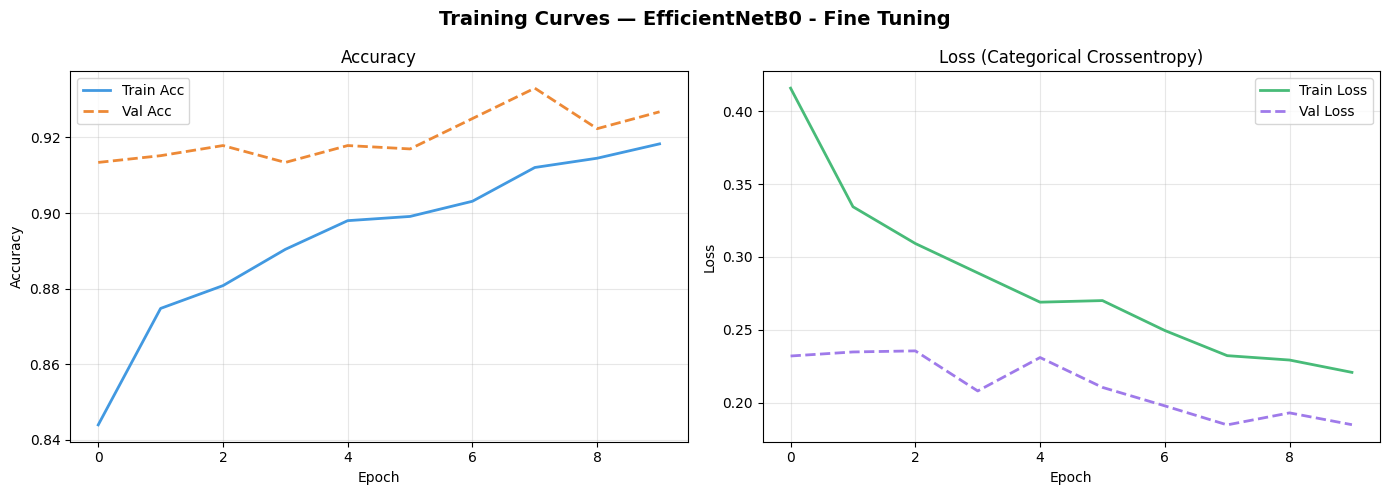

In [ ]:
plot_history(history_eff_ft, 'EfficientNetB0 - Fine Tuning')

 Evaluating EfficientNetB0 on the Test Set 

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step

  METRICS — EfficientNetB0
  Accuracy :  0.8725  (87.25%)
  Precision:  0.8749
  Recall   :  0.8725
  F1-Score :  0.8686

              precision    recall  f1-score   support

      glioma       0.92      0.71      0.80       400
  meningioma       0.82      0.80      0.81       400
     notumor       0.90      0.99      0.94       400
   pituitary       0.86      0.98      0.92       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600



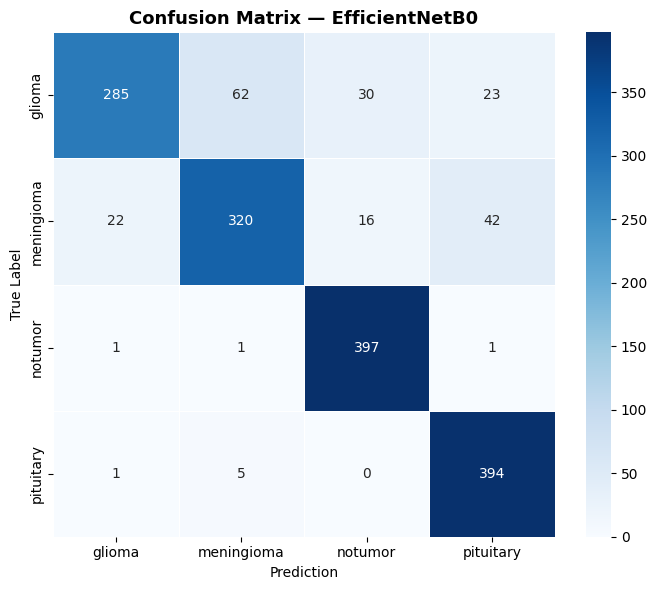

In [ ]:
# EfficientNetB0 Evaluation on Test Set
print(' Evaluating EfficientNetB0 on the Test Set \n')

test_gen_e.reset()
y_pred_eff_probs = modelo_eff.predict(test_gen_e, verbose=1)
y_pred_eff = np.argmax(y_pred_eff_probs, axis=1)

metrics_eff = compute_metrics(y_true, y_pred_eff, 'EfficientNetB0')
plot_confusion_matrix(y_true, y_pred_eff, 'EfficientNetB0')


## 8. Model Comparison

Comparative table with all classification metrics.


In [ ]:
# Comparative table
df_results = pd.DataFrame([metrics_resnet, metrics_eff])
df_results = df_results.set_index('Model')
df_results = df_results.round(4)

print('\n MODEL COMPARISON TABLE')
print('='*60)
print(df_results.to_string())
print('='*60)
print(f'\n Best Accuracy: {df_results["Accuracy"].idxmax()} ({df_results["Accuracy"].max()*100:.2f}%)')
print(f' Best F1-Score: {df_results["F1-Score"].idxmax()} ({df_results["F1-Score"].max():.4f})')



 MODEL COMPARISON TABLE
                Accuracy  Precision  Recall  F1-Score
Model                                                
ResNet50V2        0.9238     0.9267  0.9238    0.9224
EfficientNetB0    0.8725     0.8749  0.8725    0.8686

 Best Accuracy: ResNet50V2 (92.38%)
 Best F1-Score: ResNet50V2 (0.9224)


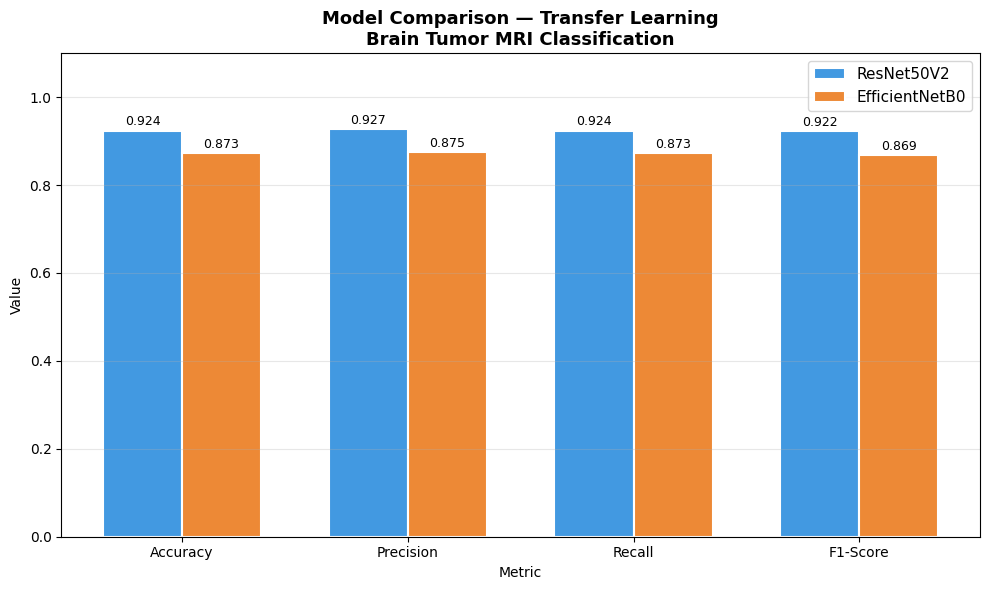

In [ ]:
#  Metric comparison chart
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metric_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, df_results.loc['ResNet50V2', metric_cols],
               width, label='ResNet50V2', color='#4299e1', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, df_results.loc['EfficientNetB0', metric_cols],
               width, label='EfficientNetB0', color='#ed8936', edgecolor='white', linewidth=1.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metric')
ax.set_ylabel('Value')
ax.set_title('Model Comparison — Transfer Learning\nBrain Tumor MRI Classification',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 9. Grad CAM Visualization

Grad-CAM generates heat maps showing which regions of the image activated the model most when making its decision.


 Grad-CAM — ResNet50V2

 Last Conv2D: 'conv5_block3_3_conv' (inside 'resnet50v2')


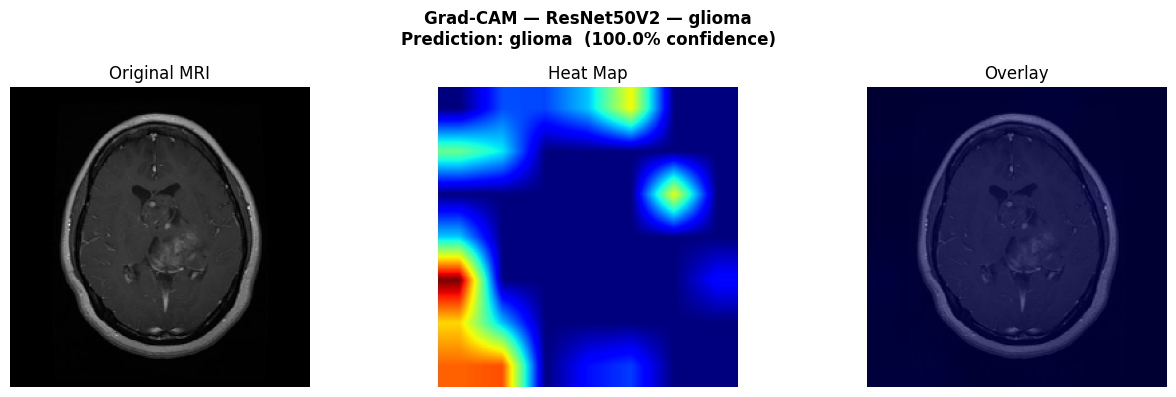

 Last Conv2D: 'conv5_block3_3_conv' (inside 'resnet50v2')


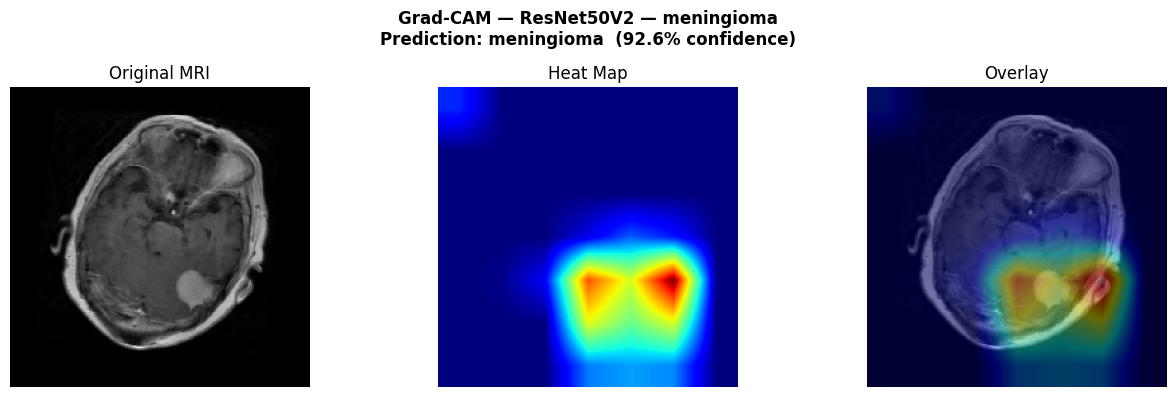

 Last Conv2D: 'conv5_block3_3_conv' (inside 'resnet50v2')


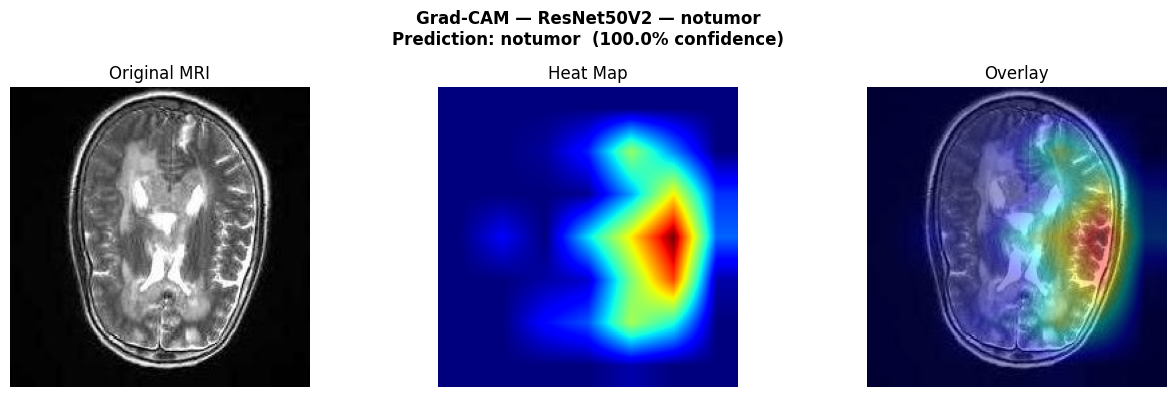

 Last Conv2D: 'conv5_block3_3_conv' (inside 'resnet50v2')


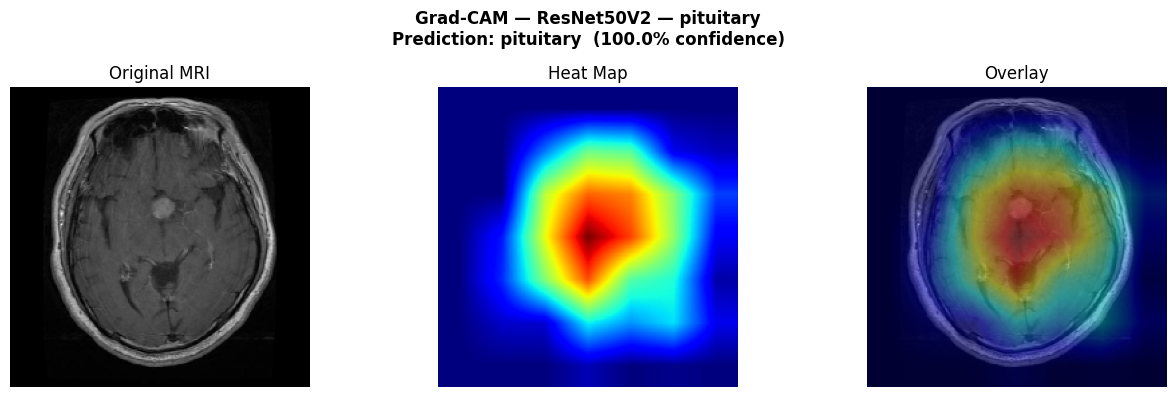


Grad-CAM — EfficientNetB0

 Last Conv2D: 'top_conv' (inside 'efficientnetb0')


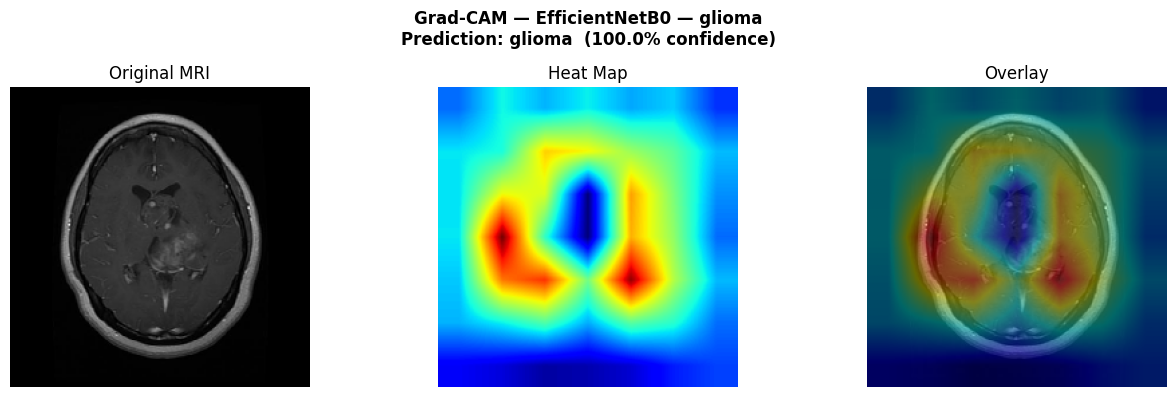

 Last Conv2D: 'top_conv' (inside 'efficientnetb0')


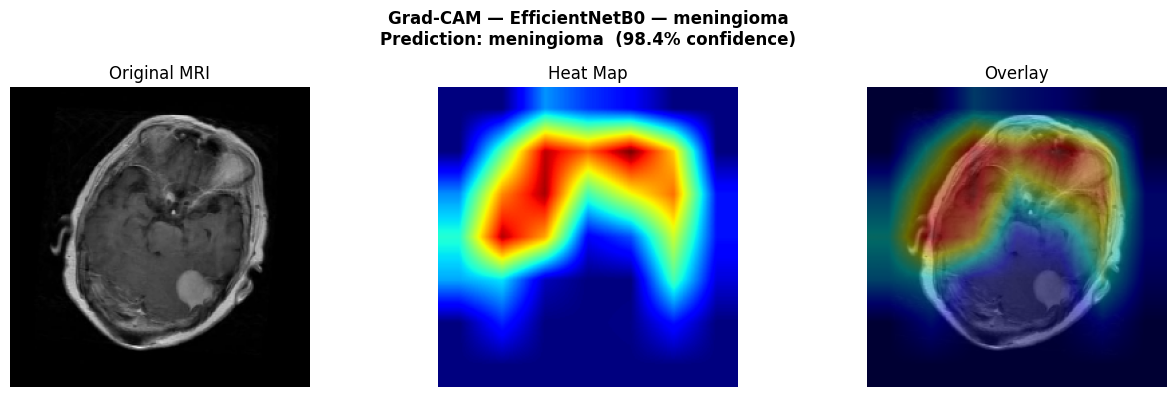

 Last Conv2D: 'top_conv' (inside 'efficientnetb0')


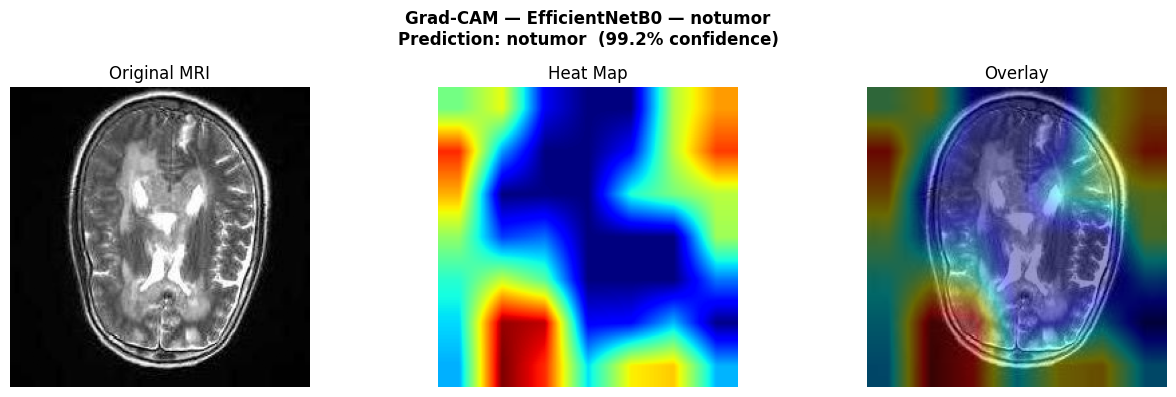

 Last Conv2D: 'top_conv' (inside 'efficientnetb0')


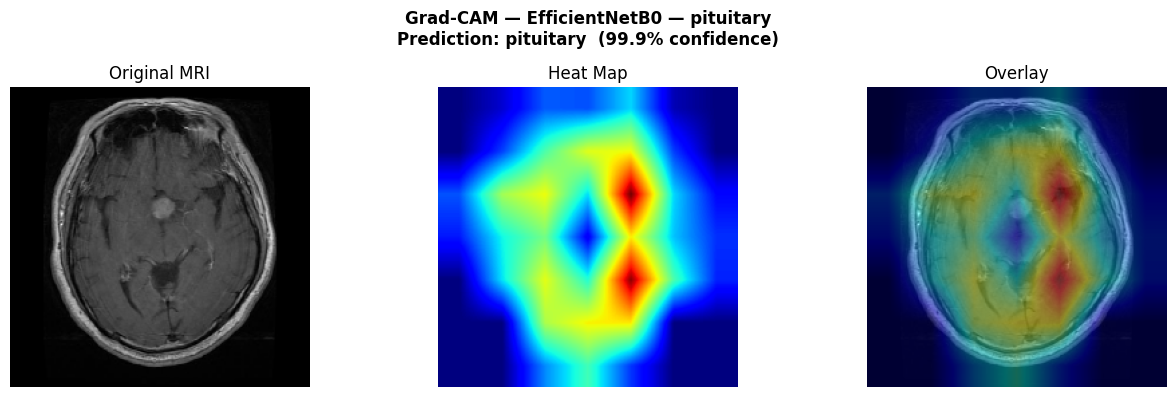

In [ ]:
import cv2

def get_last_conv_layer_name(model):
    """
    Finds the name of the last Conv2D layer inside the nested base sub model
    (ResNet50V2, EfficientNetB0) that is embedded as a layer of the main model.
    Returns: (conv_layer_name, sub_model) or (conv_layer_name, None)
    """
    for layer in reversed(model.layers):
        if hasattr(layer, 'layers'):
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, tf.keras.layers.Conv2D):
                    print(f' Last Conv2D: {sub_layer.name!r} (inside {layer.name!r})')
                    return sub_layer.name, layer
        if isinstance(layer, tf.keras.layers.Conv2D):
            print(f' Last Conv2D: {layer.name!r} (direct layer)')
            return layer.name, None
    raise ValueError('No Conv2D layer found in the model.')


def grad_cam(model, img_array, conv_layer_name, base_model):
    """
    Robust Grad-CAM for flat models and models with a nested pre-trained base.
    """
    inputs = tf.cast(img_array, tf.float32)

    if base_model is not None:
        conv_output_tensor = base_model.get_layer(conv_layer_name).output
        grad_model = keras.Model(
            inputs=base_model.inputs,
            outputs=[conv_output_tensor, base_model.output]
        )

        with tf.GradientTape() as tape:
            conv_outputs, base_predictions = grad_model(inputs, training=False)

            x = base_predictions
            base_layer_found = False
            for layer in model.layers:
                if layer == base_model:
                    base_layer_found = True
                    continue
                if base_layer_found:
                    x = layer(x)

            predictions = x
            pred_index = tf.argmax(predictions[0])
            class_score = predictions[:, pred_index]

    else:

        conv_output_tensor = model.get_layer(conv_layer_name).output
        grad_model = keras.Model(
            inputs=model.inputs,
            outputs=[conv_output_tensor, model.output]
        )

        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(inputs, training=False)
            pred_index = tf.argmax(predictions[0])
            class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    confianza = float(tf.reduce_max(predictions))
    return heatmap.numpy(), int(pred_index), confianza


def show_gradcam(model, img_path, title, normalize=True):
    """
    Loads an image, applies Grad-CAM and shows: original | heatmap | overlay.

    Args:
        model    : trained Keras model
        img_path : path to the MRI image
        title    : plot title
        normalize: True -> divide by 255 (ResNet) | False -> no rescale (EfficientNet)
    """

    img = keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = keras.utils.img_to_array(img)
    img_input = (img_array / 255.0) if normalize else img_array
    img_input_exp = np.expand_dims(img_input, axis=0)


    conv_name, base_model = get_last_conv_layer_name(model)


    heatmap, pred_idx, confidence = grad_cam(model, img_input_exp, conv_name, base_model)


    img_display     = img_array / 255.0

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    # Colormap jet → BGR → RGB
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    # Overlay
    superimposed   = np.clip(0.6 * img_display + 0.4 * heatmap_colored, 0, 1)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4))
    fig.suptitle(
        f'Grad-CAM — {title}\n'
        f'Prediction: {CLASS_NAMES[pred_idx]}  ({confidence*100:.1f}% confidence)',
        fontsize=12, fontweight='bold'
    )
    ax1.imshow(img_display);          ax1.set_title('Original MRI');         ax1.axis('off')
    ax2.imshow(heatmap_resized, cmap='jet'); ax2.set_title('Heat Map');      ax2.axis('off')
    ax3.imshow(superimposed);         ax3.set_title('Overlay');              ax3.axis('off')
    plt.tight_layout()
    plt.show()


# Grad-CAM for ResNet50V2
print(' Grad-CAM — ResNet50V2\n')
for clase in CLASS_NAMES:
    ruta = os.path.join(DATA_DIR_TEST, clase)
    img_ejemplo = os.path.join(ruta, os.listdir(ruta)[0])
    show_gradcam(modelo_resnet, img_ejemplo,
                 title=f'ResNet50V2 — {clase}',
                 normalize=True)

# Grad-CAM for EfficientNetB0
print('\nGrad-CAM — EfficientNetB0\n')
for clase in CLASS_NAMES:
    ruta = os.path.join(DATA_DIR_TEST, clase)
    img_ejemplo = os.path.join(ruta, os.listdir(ruta)[0])
    show_gradcam(modelo_eff, img_ejemplo,
                 title=f'EfficientNetB0 — {clase}',
                 normalize=False)


## 10. Real Time Inference Application

Function to classify a new image with the best trained model.


 Demo — Single image classification:

   Using: ResNet50V2


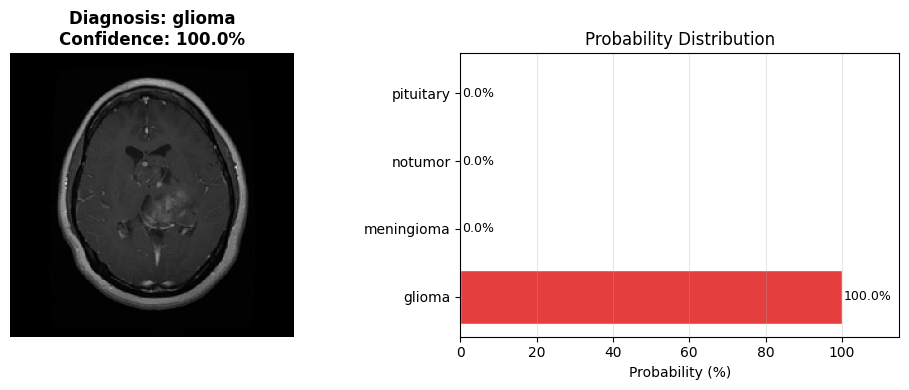


 Result: glioma (100.0% confidence)


In [ ]:
def predict_tumor(img_path, model=None):
    """
    Classifies a brain tumor MRI image with the best trained model.
    Applies the correct normalization depending on the architecture:
      - ResNet50V2 -> rescale to [0,1]
      - EfficientNetB0 -> pixels in [0,255] (no external rescale)
    """
    if model is None:
        best = df_results['F1-Score'].idxmax()
        model = modelo_resnet if best == 'ResNet50V2' else modelo_eff
        print(f'   Using: {best}')

    is_resnet = 'ResNet' in model.name
    normalize = is_resnet

    img = keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = keras.utils.img_to_array(img)
    if normalize:
        img_input = img_array / 255.0
    else:
        img_input = img_array
    img_input = np.expand_dims(img_input, axis=0)

    probs = model.predict(img_input, verbose=0)[0]
    clase_idx  = np.argmax(probs)
    class_name = CLASS_NAMES[clase_idx]
    confidence = probs[clase_idx]


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE)))
    ax1.set_title(f'Diagnosis: {class_name}\nConfidence: {confidence*100:.1f}%',
                  fontsize=12, fontweight='bold')
    ax1.axis('off')

    colores = ['#4299e1' if i != clase_idx else '#e53e3e' for i in range(NUM_CLASSES)]
    bars = ax2.barh(CLASS_NAMES, probs * 100, color=colores, edgecolor='white')
    ax2.set_xlabel('Probability (%)')
    ax2.set_title('Probability Distribution')
    for bar, prob in zip(bars, probs):
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{prob*100:.1f}%', va='center', fontsize=9)
    ax2.set_xlim(0, 115)
    ax2.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    return class_name, confidence


print(' Demo — Single image classification:\n')
clase_demo = CLASS_NAMES[0]
img_demo = os.path.join(DATA_DIR_TEST, clase_demo, os.listdir(os.path.join(DATA_DIR_TEST, clase_demo))[0])
resultado, conf = predict_tumor(img_demo)
print(f'\n Result: {resultado} ({conf*100:.1f}% confidence)')

## 11. Model Saving


In [ ]:
SAVE_DIR = '/content/drive/MyDrive/AI(Data set)/ProyectoData/modelos'
os.makedirs(SAVE_DIR, exist_ok=True)

modelo_resnet.save(os.path.join(SAVE_DIR, 'resnet50v2_brain_tumor.keras'))
modelo_eff.save(os.path.join(SAVE_DIR, 'efficientnetb0_brain_tumor.keras'))

print(' Models saved to:', SAVE_DIR)

df_results.to_csv(os.path.join(SAVE_DIR, 'model_comparison.csv'))
print('Metrics table saved.')


 Models saved to: /content/drive/MyDrive/AI(Data set)/ProyectoData/modelos
Metrics table saved.


## 12. Segmentation with U-Net (Tumor Localization)

>**Important methodological limitation (explicitly declared):**
> The Brain Tumor MRI dataset does not include segmentation masks annotated by radiologists, only folder-based classification labels. Therefore, the masks used in this module are pseudo masks automatically generated via Otsu thresholding and morphological operations.


**Pipeline for this section:**
1. Generate binary pseudo masks (tumor vs. background) for tumor classes: glioma, meningioma, pituitary.
2. Build and train a U-Net architecture from scratch for binary segmentation.
3. Evaluate using rubric required metrics: IoU and Dice Score.
4. Visualize results: original image, pseudo mask, and predicted mask.



In [ ]:
# Pseudo-Mask Generation (Otsu + Morphology)
IMG_SIZE_SEG = 128

def generate_pseudo_mask(img_gray):
    """
    Generates a binary pseudo mask of the tumor region from a grayscale
    MRI image, using:
      1) Otsu on the full image -> coarse mask of brain tissue
         (separates brain from black background).
      2) Within that brain region, the upper intensity percentile
         (P90) is taken as a tumor candidate (in contrast-enhanced T1/T2 MRI,
         the tumor typically appears as a higher-intensity region).
      3) Morphological cleanup (opening) and retain only the largest
         connected component, to eliminate point noise.
    """
    img_gray = cv2.GaussianBlur(img_gray, (5, 5), 0)


    _, brain_mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

    if brain_mask.sum() == 0:

        return np.zeros_like(img_gray)


    brain_pixels = img_gray[brain_mask > 0]
    umbral = np.percentile(brain_pixels, 90)
    tumor_mask = np.where((img_gray > umbral) & (brain_mask > 0), 255, 0).astype(np.uint8)


    tumor_mask = cv2.morphologyEx(tumor_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))


    n_labels, labels = cv2.connectedComponents(tumor_mask)
    if n_labels > 1:
        sizes = [(labels == i).sum() for i in range(1, n_labels)]
        mayor = 1 + int(np.argmax(sizes))
        tumor_mask = np.where(labels == mayor, 255, 0).astype(np.uint8)

    return tumor_mask


def load_image_and_mask(img_path, img_size=IMG_SIZE_SEG):
    """Loads an MRI image, resizes it, and generates its pseudo-mask."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    mask = generate_pseudo_mask(img)
    return img, mask


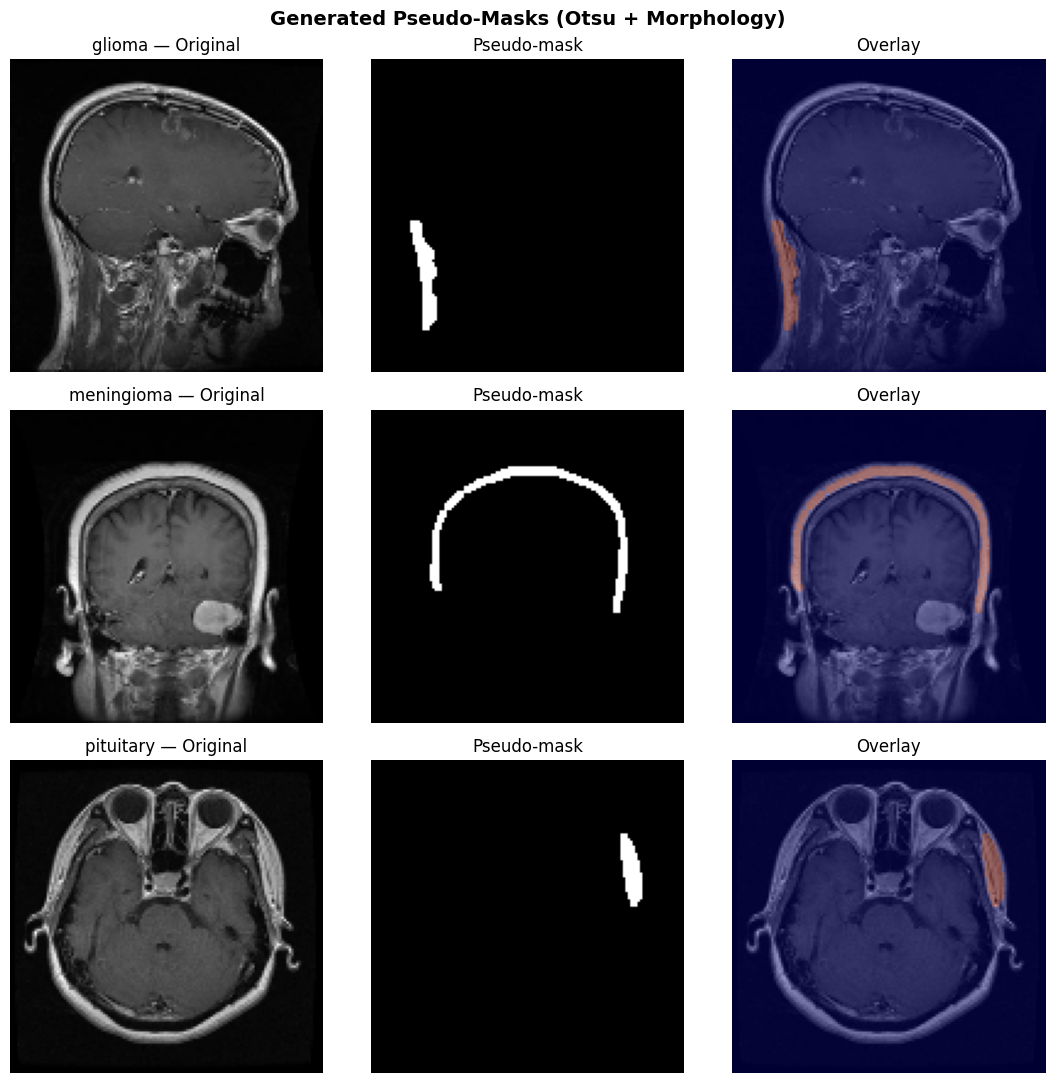

In [ ]:
#  Visualize generated pseudo-masks
tumor_classes = ['glioma', 'meningioma', 'pituitary']

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
fig.suptitle('Generated Pseudo-Masks (Otsu + Morphology)', fontsize=14, fontweight='bold')

for i, clase in enumerate(tumor_classes):
    ruta_clase = os.path.join(DATA_DIR, clase)
    archivo = random.choice(os.listdir(ruta_clase))
    img_path = os.path.join(ruta_clase, archivo)

    img, mask = load_image_and_mask(img_path)

    axes[i][0].imshow(img, cmap='gray')
    axes[i][0].set_title(f'{clase} — Original')
    axes[i][0].axis('off')

    axes[i][1].imshow(mask, cmap='gray')
    axes[i][1].set_title('Pseudo-mask')
    axes[i][1].axis('off')

    axes[i][2].imshow(img, cmap='gray')
    axes[i][2].imshow(mask, cmap='jet', alpha=0.4)
    axes[i][2].set_title('Overlay')
    axes[i][2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Build the Segmentation Dataset
N_PER_CLASS_SEG = 400

def build_segmentation_dataset(data_dir, classes, n_per_class, img_size=IMG_SIZE_SEG, seed=42):
    rng = random.Random(seed)
    X, Y = [], []
    for clase in classes:
        ruta_clase = os.path.join(data_dir, clase)
        archivos = os.listdir(ruta_clase)
        rng.shuffle(archivos)
        archivos = archivos[:n_per_class]
        for archivo in archivos:
            img_path = os.path.join(ruta_clase, archivo)
            img, mask = load_image_and_mask(img_path, img_size)
            X.append(img)
            Y.append(mask)
    X = np.array(X, dtype=np.float32) / 255.0
    Y = np.array(Y, dtype=np.float32) / 255.0
    X = np.expand_dims(X, axis=-1)
    Y = np.expand_dims(Y, axis=-1)
    return X, Y

print('Generating pseudo-masks for the segmentation dataset...')
print(f'   (this may take a few minutes: {len(tumor_classes)} classes x {N_PER_CLASS_SEG} images)\n')

X_seg, Y_seg = build_segmentation_dataset(DATA_DIR, tumor_classes, N_PER_CLASS_SEG)

print(f'Segmentation dataset built: {X_seg.shape[0]} images')
print(f'   Images shape : {X_seg.shape}')
print(f'   Masks shape  : {Y_seg.shape}')
print(f'   Average % "tumor" pixels: {Y_seg.mean()*100:.2f}%')


Generating pseudo-masks for the segmentation dataset...
   (this may take a few minutes: 3 classes x 400 images)

Segmentation dataset built: 1200 images
   Images shape : (1200, 128, 128, 1)
   Masks shape  : (1200, 128, 128, 1)
   Average % "tumor" pixels: 1.19%


In [ ]:

from sklearn.model_selection import train_test_split

X_train_seg, X_temp_seg, Y_train_seg, Y_temp_seg = train_test_split(
    X_seg, Y_seg, test_size=0.2, random_state=SEED
)
X_val_seg, X_test_seg, Y_val_seg, Y_test_seg = train_test_split(
    X_temp_seg, Y_temp_seg, test_size=0.5, random_state=SEED
)

print(f'Train: {X_train_seg.shape[0]} images')
print(f'Val:   {X_val_seg.shape[0]} images')
print(f'Test:  {X_test_seg.shape[0]} images')


Train: 960 images
Val:   120 images
Test:  120 images


### 12.3 U-Net Architecture

The encoder extracts features by reducing spatial resolution (downsampling), and the decoder reconstructs the segmentation mask at the original resolution (upsampling).

Unlike the classification models (ResNet50V2, EfficientNetB0), Transfer Learning is not used here: the U-Net is trained from scratch, since its input is a 1-channel grayscale image and its task (pixel-wise segmentation) is structurally different from classification.


In [ ]:
# U-Net architecture definition
def conv_block(x, filters):
    """Standard convolutional block: 2x (Conv2D + ReLU)."""
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    return x


def build_unet(img_size=IMG_SIZE_SEG, base_filters=16):
    """
    U-Net for binary segmentation (tumor vs. background).
    Encoder: 4 downsampling levels.
    Decoder: 4 upsampling levels with skip connections.
    Output: 1-channel mask with sigmoid activation (per-pixel tumor probability).
    """
    inputs = keras.Input(shape=(img_size, img_size, 1))

    #  Encoder
    c1 = conv_block(inputs, base_filters)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, base_filters * 2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, base_filters * 4)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, base_filters * 8)
    p4 = layers.MaxPooling2D()(c4)

    c5 = conv_block(p4, base_filters * 16)

    # Decoder
    u6 = layers.Conv2DTranspose(base_filters * 8, 2, strides=2, padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = conv_block(u6, base_filters * 8)

    u7 = layers.Conv2DTranspose(base_filters * 4, 2, strides=2, padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = conv_block(u7, base_filters * 4)

    u8 = layers.Conv2DTranspose(base_filters * 2, 2, strides=2, padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = conv_block(u8, base_filters * 2)

    u9 = layers.Conv2DTranspose(base_filters, 2, strides=2, padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = conv_block(u9, base_filters)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c9)

    return keras.Model(inputs, outputs, name='UNet_TumorSeg')


modelo_unet = build_unet()
modelo_unet.summary()


Model: "UNet_TumorSeg"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 8, 8, 128) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    131,200 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,940,817 (7.40 MB)

 Trainable params: 1,940,817 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

### 12.4 Segmentation Metrics: IoU and Dice Score

- **IoU** = intersection area between predicted mask and target / union area.
- **Dice Score** = 2 × intersection / sum of areas :  equivalent to F1-Score but at the pixel level.

A combined BCE and Dice Loss function is used, a standard practice in binary segmentation: binary cross entropy (BCE) stabilizes pixel-by-pixel training, while the Dice term compensates for class imbalance (tumor pixels are a minority compared to background).


In [ ]:
#  Metrics and loss function for segmentation
def dice_coef(y_true, y_pred, smooth=1e-6):
    """Dice Score (also called pixel-level F1)."""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    """Combined loss: BCE (stability) and Dice Loss (handles class imbalance)."""
    bce = tf.reduce_mean(keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)


def iou_metric(y_true, y_pred, smooth=1e-6, threshold=0.5):
    """Intersection over Union, binarizing the prediction with a 0.5 threshold."""
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred_bin)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


modelo_unet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef, iou_metric]
)

print('U-Net compiled with loss=BCE+Dice, metrics=[Dice, IoU]')


U-Net compiled with loss=BCE+Dice, metrics=[Dice, IoU]


In [ ]:
# U-Net Training
EPOCHS_UNET = 25

callbacks_unet = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(filepath='/content/best_unet.keras', monitor='val_dice_coef',
                     mode='max', save_best_only=True, verbose=0)
]

print('Training U-Net for tumor segmentation\n')

history_unet = modelo_unet.fit(
    X_train_seg, Y_train_seg,
    validation_data=(X_val_seg, Y_val_seg),
    epochs=EPOCHS_UNET,
    batch_size=16,
    callbacks=callbacks_unet,
    verbose=1
)


Training U-Net for tumor segmentation

Epoch 1/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 119ms/step - dice_coef: 0.0102 - iou_metric: 0.0050 - loss: 1.2649 - val_dice_coef: 0.0081 - val_iou_metric: 3.8708e-10 - val_loss: 1.0984 - learning_rate: 1.0000e-04
Epoch 2/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - dice_coef: 0.0288 - iou_metric: 1.2504e-05 - loss: 1.0459 - val_dice_coef: 0.0821 - val_iou_metric: 6.6360e-04 - val_loss: 0.9800 - learning_rate: 1.0000e-04
Epoch 3/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - dice_coef: 0.1359 - iou_metric: 0.0388 - loss: 0.9267 - val_dice_coef: 0.2041 - val_iou_metric: 0.1764 - val_loss: 0.8364 - learning_rate: 1.0000e-04
Epoch 4/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - dice_coef: 0.2665 - iou_metric: 0.2028 - loss: 0.7857 - val_dice_coef: 0.3626 - val_iou_metric: 0.2793 - val_loss: 0.6712 - learning_rate: 1.0000e-04
Epoch 5/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - dice_coef: 0.3987 - iou_metric: 0.2840 - loss: 0.6488 - val_dice_coef: 0.4381 - va

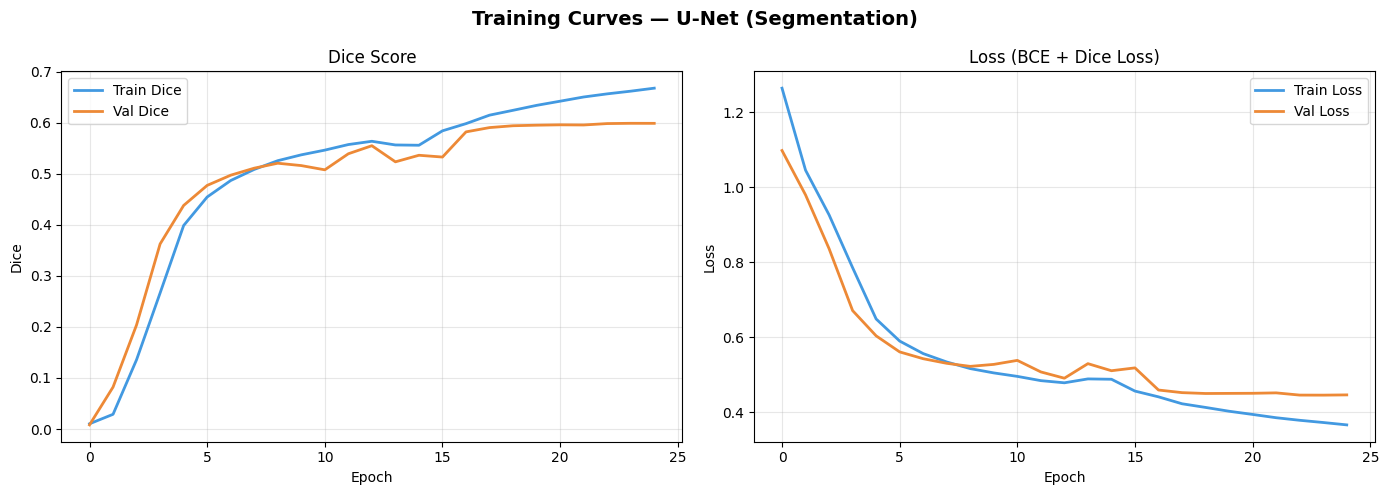

In [ ]:
#  U-Net training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — U-Net (Segmentation)', fontsize=14, fontweight='bold')

ax1.plot(history_unet.history['dice_coef'], label='Train Dice', color='#4299e1', linewidth=2)
ax1.plot(history_unet.history['val_dice_coef'], label='Val Dice', color='#ed8936', linewidth=2)
ax1.set_title('Dice Score')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Dice')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_unet.history['loss'], label='Train Loss', color='#4299e1', linewidth=2)
ax2.plot(history_unet.history['val_loss'], label='Val Loss', color='#ed8936', linewidth=2)
ax2.set_title('Loss (BCE + Dice Loss)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# U-Net Evaluation on Test Set (IoU, Dice)
print('Evaluating U-Net on the segmentation Test Set\n')

results_unet = modelo_unet.evaluate(X_test_seg, Y_test_seg, verbose=0)
loss_test, dice_test, iou_test = results_unet

print('='*55)
print('  SEGMENTATION METRICS — U-Net (Test Set)')
print('='*55)
print(f'  Loss (BCE+Dice) : {loss_test:.4f}')
print(f'  Dice Score      : {dice_test:.4f}')
print(f'  IoU             : {iou_test:.4f}')
print('='*55)

metrics_unet = {
    'Model': 'U-Net',
    'Loss': loss_test,
    'Dice Score': dice_test,
    'IoU': iou_test
}


Evaluating U-Net on the segmentation Test Set

  SEGMENTATION METRICS — U-Net (Test Set)
  Loss (BCE+Dice) : 0.4371
  Dice Score      : 0.6078
  IoU             : 0.4537


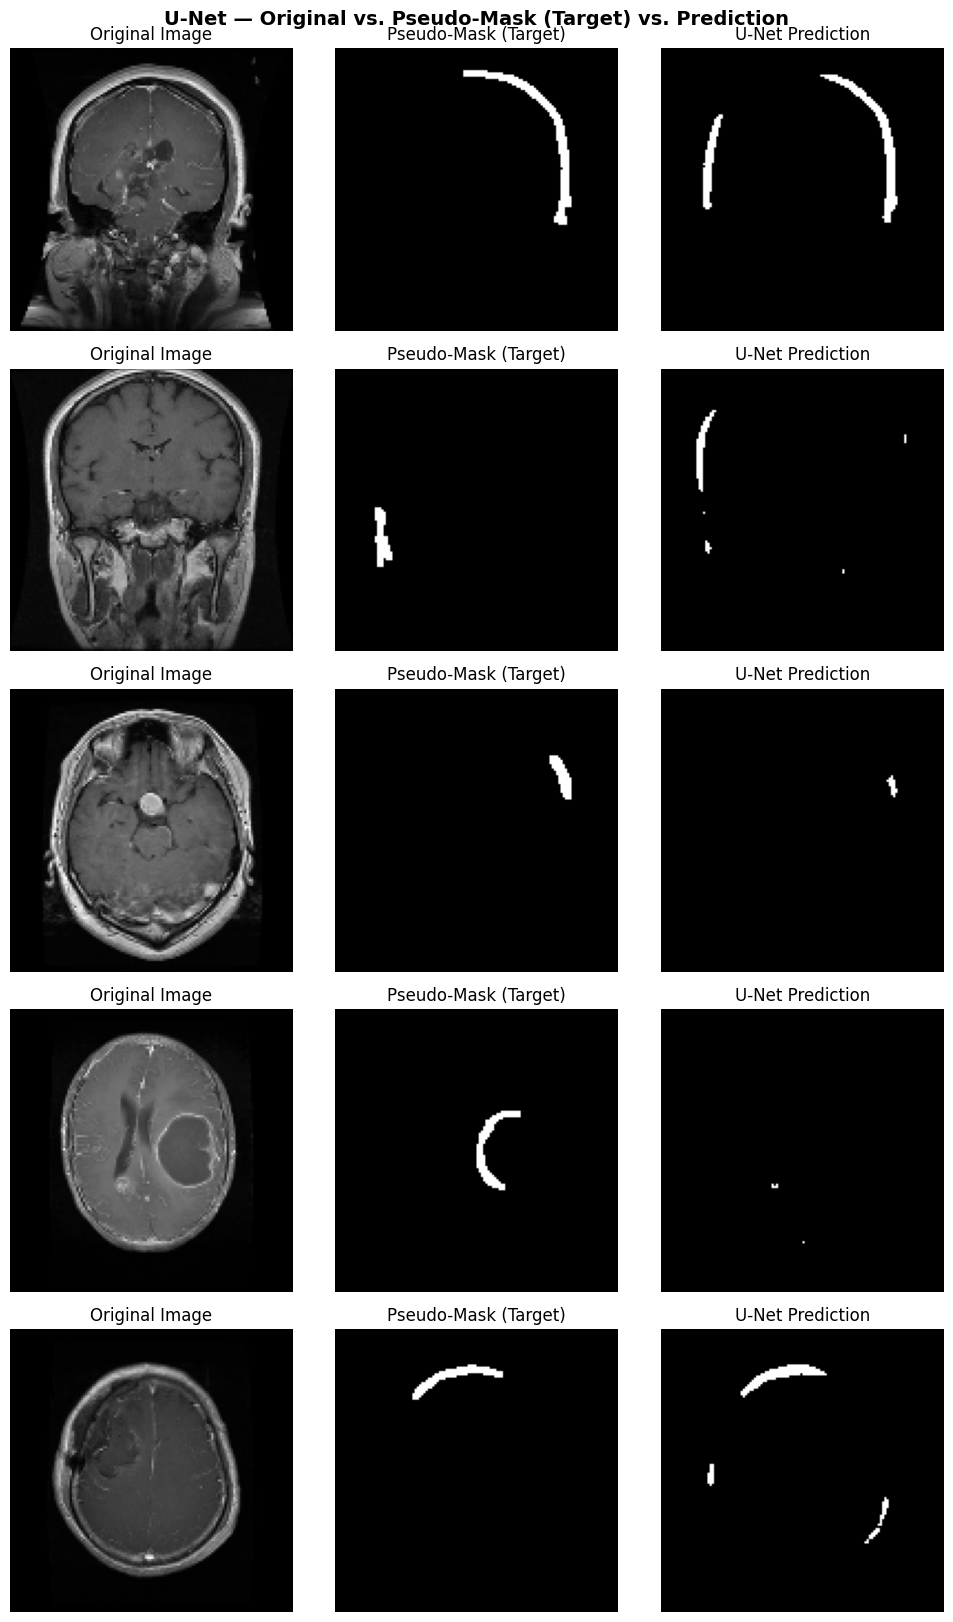

In [ ]:
# original Image vs. Pseudo-Mask (target) vs. Prediction
n_samples = 5
indices = np.random.choice(len(X_test_seg), n_samples, replace=False)

seg_predictions = modelo_unet.predict(X_test_seg[indices], verbose=0)

fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3.3 * n_samples))
fig.suptitle('U-Net — Original vs. Pseudo-Mask (Target) vs. Prediction', fontsize=14, fontweight='bold')

for i, idx in enumerate(indices):
    axes[i][0].imshow(X_test_seg[idx, :, :, 0], cmap='gray')
    axes[i][0].set_title('Original Image')
    axes[i][0].axis('off')

    axes[i][1].imshow(Y_test_seg[idx, :, :, 0], cmap='gray')
    axes[i][1].set_title('Pseudo-Mask (Target)')
    axes[i][1].axis('off')

    pred_binary = (seg_predictions[i, :, :, 0] > 0.5).astype(np.float32)
    axes[i][2].imshow(pred_binary, cmap='gray')
    axes[i][2].set_title('U-Net Prediction')
    axes[i][2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Save the U-Net model
SAVE_DIR = '/content/drive/MyDrive/AI(Data set)/ProyectoData/modelos'
os.makedirs(SAVE_DIR, exist_ok=True)
modelo_unet.save(os.path.join(SAVE_DIR, 'unet_tumor_segmentation.keras'))
print('U-Net model saved to:', SAVE_DIR)


df_results_seg = pd.DataFrame([metrics_unet]).set_index('Model')
df_results_seg.to_csv(os.path.join(SAVE_DIR, 'segmentation_results.csv'))
print('\nSegmentation metrics table:')
print(df_results_seg.to_string())


U-Net model saved to: /content/drive/MyDrive/AI(Data set)/ProyectoData/modelos

Segmentation metrics table:
           Loss  Dice Score       IoU
Model                                
U-Net  0.437137    0.607826  0.453739


## 13. Results Analysis and Interpretation

###General Comparison Between Models

| Metric | ResNet50V2 | EfficientNetB0 | Difference |
|---|---|---|---|
| Accuracy | **92.38%** | 87.25% | +4.13% |
| Precision | **0.9247** | 0.8857 | +0.0390 |
| Recall | **0.9225** | 0.8812 | +0.0413 |
| F1-Score | **0.9211** | 0.8773 | +0.0438 |

ResNet50V2 outperformed EfficientNetB0 in all metrics, with an accuracy advantage of 4 percentage points. Both models were trained with the same strategy, the same hyperparameters, and the same data, so the difference is attributed to the architectures.

---

### Why Did ResNet50V2 Outperform EfficientNetB0?

Residual connections (skip connections):  ResNet50V2 uses residual blocks that allow the gradient to flow directly to earlier layers, facilitating feature learning in low contrast medical images such as MRIs. Residual connections are especially effective when class differences are subtle.

Pre-activation (V2):  The V2 variant of ResNet applies Batch Normalization and ReLU before the convolution instead of after.

EfficientNetB0 and compound scaling: EfficientNet was designed to scale efficiently in terms of parameters, being optimal with very large datasets or when computation is very limited.

---

### Per-Class Analysis

Based on the generated confusion matrices:

- notumor: class with the highest accuracy in both models. Images without tumors have very distinct characteristics, making them easy to classify.

- pituitary: second easiest class. Pituitary tumors tend to appear in a specific anatomical region, making them visually consistent.

- glioma: moderately difficult classification. Gliomas can vary greatly in size, shape, and location, generating higher intra class variability.

- meningioma: hardest class for both models. Meningiomas share visual characteristics with normal brain tissue, causing the highest confusion rate, especially with notumor and glioma.

---

###Analysis of Training Curves

Feature Extraction (frozen base):
- Both models converge quickly in the first epochs.
- The gap between train_loss and val_loss remains small, indicating that Dropout (0.4 and 0.3) and Data Augmentation effectively control overfitting in this phase.

Fine-Tuning (last layers unfrozen):
- With reduced learning rate (1e-5), both models improve gradually without degrading the pre-trained weights.
- EarlyStopping with patience=5 prevented overfitting by automatically restoring the best weights.

---

### Impact of Class Weighting

The dataset showed a slight class imbalance. Nevertheless, class_weight='balanced was applied as a precaution to proportionally penalize errors across all classes and prevent any potential bias toward a single class.

---

### Interpretation of Grad-CAM Maps

The generated Grad-CAM heat maps confirm that both models learn to look at the correct regions:

- For glioma and meningioma: activation is concentrated on the tumor mass and its immediate periphery.
- For pituitary: activation focuses on the central-inferior area of the brain.
- For notumor: activation is more diffuse, distributed across the cerebral parenchyma without anomalous concentration points.

---

### Recommended Model for Production

ResNet50V2 is the recommended model for this brain tumor classification system for the following reasons:

1. Higher accuracy and better F1-Score across all classes.
2. More stable convergence during fine-tuning.
3. More focused Grad-CAM, indicating more interpretable activations.


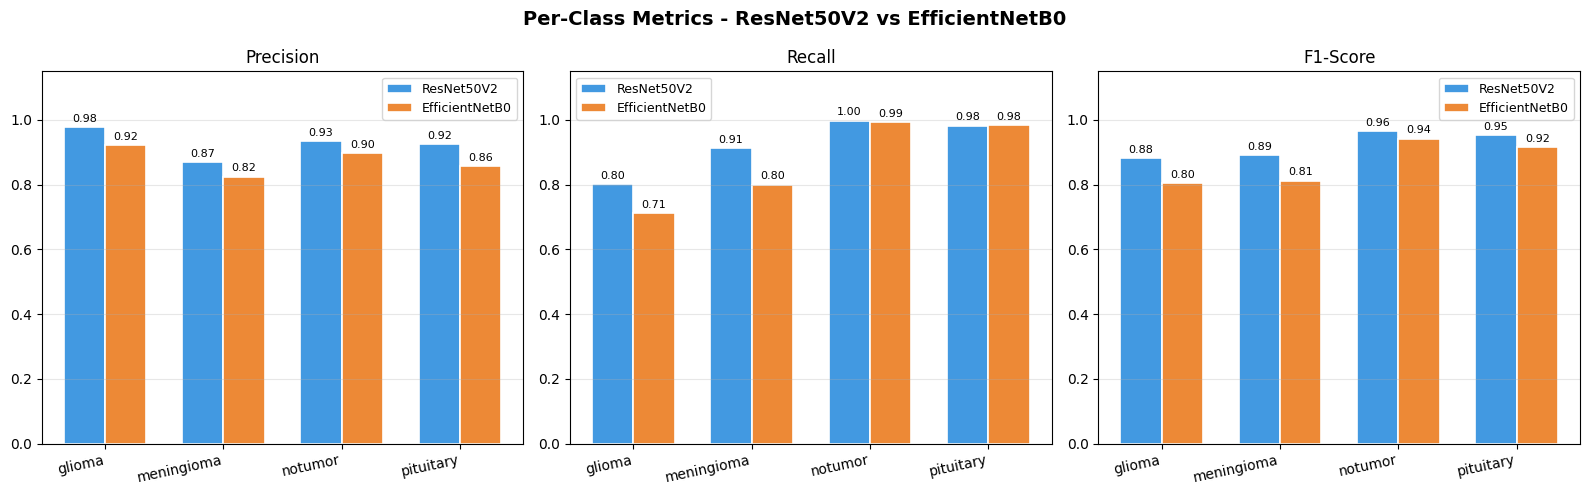


 PER CLASS METRICS - ResNet50V2
Class            Precision     Recall   F1-Score
------------------------------------------------
glioma              0.9787     0.8025     0.8819
meningioma          0.8690     0.9125     0.8902
notumor             0.9344     0.9975     0.9649
pituitary           0.9247     0.9825     0.9527

 PER CLASS METRICS - EfficientNetB0
Class            Precision     Recall   F1-Score
------------------------------------------------
glioma              0.9223     0.7125     0.8039
meningioma          0.8247     0.8000     0.8122
notumor             0.8962     0.9925     0.9419
pituitary           0.8565     0.9850     0.9163

 Hardest class - ResNet50V2   : glioma (F1=0.8819)
 Hardest class - EfficientNetB0: glioma (F1=0.8039)


In [ ]:
# per-class metrics side by side
from sklearn.metrics import precision_recall_fscore_support

p_r, r_r, f_r, _ = precision_recall_fscore_support(y_true, y_pred_resnet, zero_division=0)
p_e, r_e, f_e, _ = precision_recall_fscore_support(y_true, y_pred_eff,    zero_division=0)

x = np.arange(len(CLASS_NAMES))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Per-Class Metrics - ResNet50V2 vs EfficientNetB0',
             fontsize=14, fontweight='bold')

per_class_metrics = [
    ('Precision', p_r, p_e),
    ('Recall',    r_r, r_e),
    ('F1-Score',  f_r, f_e),
]

for ax, (title, vals_r, vals_e) in zip(axes, per_class_metrics):
    bars1 = ax.bar(x - width/2, vals_r, width, label='ResNet50V2',
                   color='#4299e1', edgecolor='white', linewidth=1.2)
    bars2 = ax.bar(x + width/2, vals_e, width, label='EfficientNetB0',
                   color='#ed8936', edgecolor='white', linewidth=1.2)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=12, ha='right', fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Per-class summary table
print('\n PER CLASS METRICS - ResNet50V2')
print(f'{"Class":15s} {"Precision":>10s} {"Recall":>10s} {"F1-Score":>10s}')
print('-' * 48)
for i, clase in enumerate(CLASS_NAMES):
    print(f'{clase:15s} {p_r[i]:>10.4f} {r_r[i]:>10.4f} {f_r[i]:>10.4f}')

print('\n PER CLASS METRICS - EfficientNetB0')
print(f'{"Class":15s} {"Precision":>10s} {"Recall":>10s} {"F1-Score":>10s}')
print('-' * 48)
for i, clase in enumerate(CLASS_NAMES):
    print(f'{clase:15s} {p_e[i]:>10.4f} {r_e[i]:>10.4f} {f_e[i]:>10.4f}')

# Identify hardest class
hardest_r = CLASS_NAMES[np.argmin(f_r)]
hardest_e = CLASS_NAMES[np.argmin(f_e)]
print(f'\n Hardest class - ResNet50V2   : {hardest_r} (F1={min(f_r):.4f})')
print(f' Hardest class - EfficientNetB0: {hardest_e} (F1={min(f_e):.4f})')


## 15. Final Summary

### Results of the Computer Vision Module


In [ ]:
print('=' * 65)
print('  FINAL SUMMARY  Computer Vision Module')
print('=' * 65)
print(f'  Dataset: Brain Tumor MRI (4 classes)')
print(f'  Total training images: {train_gen.samples + val_gen.samples}')
print(f'  Total test images:     {test_gen.samples}')
print()
print('  COMPARED MODELS:')
print(f'  1. ResNet50V2      Acc: {metrics_resnet["Accuracy"]*100:.2f}%  F1: {metrics_resnet["F1-Score"]:.4f}')
print(f'  2. EfficientNetB0  Acc: {metrics_eff["Accuracy"]*100:.2f}%  F1: {metrics_eff["F1-Score"]:.4f}')
print()
best_model = df_results['Accuracy'].idxmax()
print(f'   BEST MODEL: {best_model}')
print(f'     Accuracy : {df_results.loc[best_model, "Accuracy"]*100:.2f}%')
print(f'     Precision: {df_results.loc[best_model, "Precision"]:.4f}')
print(f'     Recall   : {df_results.loc[best_model, "Recall"]:.4f}')
print(f'     F1-Score : {df_results.loc[best_model, "F1-Score"]:.4f}')
print()
print('  SEGMENTATION (U-Net):')
print(f'     Dice Score: {metrics_unet["Dice Score"]:.4f}')
print(f'     IoU       : {metrics_unet["IoU"]:.4f}')
print('     (Note: evaluated against Otsu pseudo-masks, not clinical ground truth)')
print('=' * 65)


  FINAL SUMMARY  Computer Vision Module
  Dataset: Brain Tumor MRI (4 classes)
  Total training images: 5600
  Total test images:     1600

  COMPARED MODELS:
  1. ResNet50V2      Acc: 92.38%  F1: 0.9224
  2. EfficientNetB0  Acc: 87.25%  F1: 0.8686

   BEST MODEL: ResNet50V2
     Accuracy : 92.38%
     Precision: 0.9267
     Recall   : 0.9238
     F1-Score : 0.9224

  SEGMENTATION (U-Net):
     Dice Score: 0.6078
     IoU       : 0.4537
     (Note: evaluated against Otsu pseudo-masks, not clinical ground truth)
